# Machine Learning: Rule Based Models

[Back to Machine Learning guideline](Machine Learning.html)


## **Rule Based Models**
Rule-based models are a class of models that make predictions using explicit “if–then” logical rules, where the input space is partitioned based on conditions and each region is assigned an output. Instead of learning continuous functions like linear models or neural networks, they search within a discrete space of possible rules to minimize prediction error. These models are highly interpretable and transparent, making them suitable for simple tasks or as baseline methods, but their limited expressive power makes them less effective for capturing complex nonlinear patterns.

### **1 Rule(1R)**
1R (One Rule) is a simple rule-based algorithm that generates **classification rules** using a single feature and selects the one with the lowest error, making it a highly interpretable but limited baseline model.

#### **Pseudocode**:
```
For each attribute,
    For each value of that attribute, make a rule as follows:
        - count how often each class appears
        - find the most frequent class
        - make the rule assign that class to this attribute value.
    Calculate the error rate of the rules.
Choose the rule with the smallest error rate.
```

#### **OneR Calculation Example**

Suppose we have the following dataset:

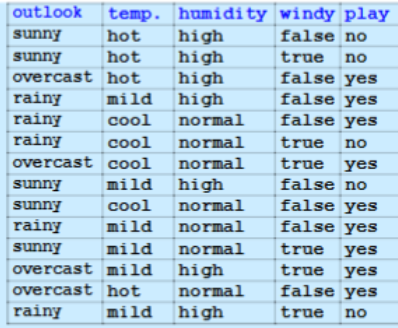

For each class of each feature, calculate its error:

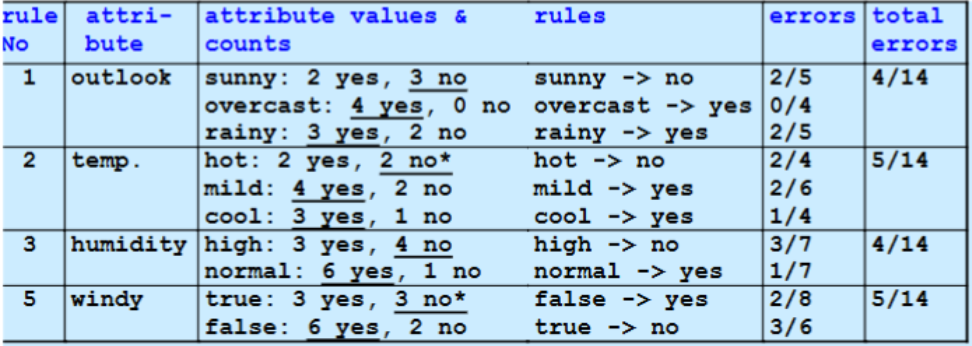

Choose the best feature with the lowest error, for ties-break, we can have random choice or by other methods:

- if "outlook= unny" the "play=no"
- elseif "outlook=overcast" then "play=yes"
- elseif "outlook=rainy" then "play=yes"

<details>
<summary>Python Implementation</summary>
    
```python
import pandas as pd
from collections import Counter

class OneR:
    def fit(self, X, y):
        X = pd.DataFrame(X)
        y = pd.Series(y)

        self.best_feature = None
        self.rules = {}
        self.default_class = y.mode()[0]
        best_error = float("inf")

        for feature in X.columns:
            feature_rules = {}
            errors = 0

            for value in X[feature].unique():
                subset_y = y[X[feature] == value]
                majority_class = subset_y.mode()[0]
                feature_rules[value] = majority_class

                errors += (subset_y != majority_class).sum()

            if errors < best_error:
                best_error = errors
                self.best_feature = feature
                self.rules = feature_rules

        return self

    def predict(self, X):
        X = pd.DataFrame(X)
        preds = []

        for value in X[self.best_feature]:
            preds.append(self.rules.get(value, self.default_class))

        return preds

# Examples
X = pd.DataFrame({
    "Weather": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Sunny"],
    "Humidity": ["High", "High", "High", "Low", "Low", "Low"]
})

y = ["No", "No", "Yes", "Yes", "Yes", "No"]

model = OneR()
model.fit(X, y)

print("Best feature:", model.best_feature)
print("Rules:", model.rules)
print("Predictions:", model.predict(X))
```
</details>

<details>
<summary>Python mlxtend Implementation</summary>

```python
from mlxtend.classifier import OneRClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = pd.DataFrame({
    "Weather": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Sunny"],
    "Humidity": ["High", "High", "High", "Low", "Low", "Low"]
})

y = ["No", "No", "Yes", "Yes", "Yes", "No"]

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

model = OneRClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Selected feature index:", model.feature_idx_)
```
</details>

### **PRISM**
PRISM is a rule-based classification algorithm that follows a covering approach, generating if–then rules sequentially for each class by iteratively adding conditions that maximize rule accuracy (p/t) until the rule achieves high class purity and covers only instances of the target class, after which covered examples are removed. Its main advantage is high interpretability, as it produces clear and human-readable rules without relying on complex structures like trees, and it can capture more specific patterns than simple rule learners such as 1R. However, it may generate a large number of rules, is computationally more expensive, and can overfit the training data if rules become too specific. PRISM is most suitable for problems where interpretability is important, datasets are relatively small to medium-sized, and where class-specific rule extraction is desired, such as in medical or decision-support systems.

In contrast, decision trees use a **divide-and-conquer approach**, recursively splitting the entire dataset based on attributes that best separate classes (e.g., information gain). While both methods select the best condition at each step, PRISM focuses on building high-precision rules, whereas decision trees focus on partitioning the data to improve overall class separation.

| Aspect          | PRISM                         | Decision Tree                 |
|-----------------|------------------------------|-------------------------------|
| Approach        | Covering approach            | Divide-and-conquer approach   |
| Construction    | Rule-by-rule generation      | Tree structure                |
| Data handling   | Removes covered instances    | Retains all instances         |
| Strategy        | Bottom-up (rule construction)| Top-down (recursive splitting)|

#### **Pseudocode**:
```
For each class C
    Initialize E to the instance set
    While E contains instances in class C
        Create a rule R with an empty LHS that predicts C
        Until R is perfect do
            For each attribute A not mentioned in R and each value V
                Consider adding the condition A=v to the LHS of R
            Select A and v to maximize p/t
            (break ties by choosing the condition with the largest p)
            Add A=v to R
        Remove the instances covered by R from E
```

#### **PRISM Calculation Example**
| A | B | C | Class |
|---:|---|---|------|
| m | x | u | Y |
| m | x | v | Y |
| n | y | u | N |
| m | y | v | Y |
| m | x | u | N |
| n | y | v | N |

- Start with an empty rule: "if ? then Class = Y"
- $\left\{\begin{aligned} A = m &\quad \frac{3}{4} \\ A = n &\quad 0 \\ \end{aligned} \right.$ $\left\{\begin{aligned} B = x &\quad \frac{2}{3} \\ B = y &\quad \frac{1}{3} \\ \end{aligned} \right.$ $\left\{\begin{aligned} C = u &\quad \frac{1}{3} \\ C = v &\quad \frac{2}{3} \\ \end{aligned} \right.$
- Choose the rule with the highest accuracy: $\text{A} = \text{m}$($\frac{3}{4}$). Current rule: "if A = m then Class = Y".
- Only keep the examples with A = m, then we have $\left\{\begin{aligned} B = x &\quad \frac{2}{3} \\ B = y &\quad \frac{1}{1} \\ \end{aligned} \right.$ $\left\{\begin{aligned} C = u &\quad \frac{1}{2} \\ C = v &\quad \frac{2}{2} \\ \end{aligned} \right.$
- Tie break: for the examples with the same accuracy, we could choose the first one randomly, if the accuracy is 1, choose the one with the greater coverage.
- The final rule: "if A = m & C = v then Class = Y"

<details>
<summary>Python Implementation</summary>

```python
import pandas as pd
from collections import Counter

class SimplePRISM:
    def __init__(self):
        self.rules = []
        self.default_class = None

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        self.default_class = y.mode()[0]
        classes = y.unique()

        for target_class in classes:
            data = X.copy()
            data["_class"] = y

            while (data["_class"] == target_class).sum() > 0:
                rule = {}
                current_data = data.copy()

                while True:
                    best_condition = None
                    best_score = -1
                    best_coverage = -1

                    for feature in X.columns:
                        if feature in rule:
                            continue

                        for value in current_data[feature].unique():
                            subset = current_data[current_data[feature] == value]
                            total = len(subset)
                            positive = (subset["_class"] == target_class).sum()

                            if total == 0:
                                continue

                            score = positive / total

                            if score > best_score or (
                                score == best_score and positive > best_coverage
                            ):
                                best_score = score
                                best_coverage = positive
                                best_condition = (feature, value)

                    if best_condition is None:
                        break

                    feature, value = best_condition
                    rule[feature] = value
                    current_data = current_data[current_data[feature] == value]

                    positive = (current_data["_class"] == target_class).sum()
                    total = len(current_data)

                    if positive == total:
                        break

                self.rules.append((rule, target_class))

                # 删除被这条规则覆盖的 target_class 样本
                mask = pd.Series(True, index=data.index)
                for feature, value in rule.items():
                    mask &= data[feature] == value

                covered_target = mask & (data["_class"] == target_class)
                data = data[~covered_target]

        return self

    def predict_one(self, row):
        for rule, label in self.rules:
            matched = True
            for feature, value in rule.items():
                if row[feature] != value:
                    matched = False
                    break

            if matched:
                return label

        return self.default_class

    def predict(self, X):
        X = pd.DataFrame(X)
        return [self.predict_one(row) for _, row in X.iterrows()]

    def print_rules(self):
        for i, (rule, label) in enumerate(self.rules, 1):
            conditions = " AND ".join([f"{k} = {v}" for k, v in rule.items()])
            print(f"Rule {i}: IF {conditions} THEN class = {label}")
        print(f"Default: class = {self.default_class}")


data = pd.DataFrame({
    "Age": ["young", "young", "young", "young", "pre", "pre", "pre", "pre"],
    "Astigmatism": ["yes", "yes", "no", "no", "yes", "yes", "no", "no"],
    "Tear": ["normal", "reduced", "normal", "reduced", "normal", "reduced", "normal", "reduced"],
    "Lens": ["hard", "none", "soft", "none", "hard", "none", "soft", "none"]
})

X = data[["Age", "Astigmatism", "Tear"]]
y = data["Lens"]

model = SimplePRISM()
model.fit(X, y)

model.print_rules()

pred = model.predict(X)
print(pred)
```
</details>